# Dunnhumby Complete Journey - Exploratory Data Analysis
**Team ProAnalytics**

Explore the real Dunnhumby dataset before running the uplift modeling pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

## 1. Load Data

In [2]:
# Load all tables
transactions = pd.read_csv('data/transaction_data.csv')
demographics = pd.read_csv('data/hh_demographic.csv')
campaigns = pd.read_csv('data/campaign_table.csv')
campaign_desc = pd.read_csv('data/campaign_desc.csv')
coupons = pd.read_csv('data/coupon.csv')
coupon_redempt = pd.read_csv('data/coupon_redempt.csv')
causal_data = pd.read_csv('data/causal_data.csv')

print(f"Transactions: {len(transactions):,} rows")
print(f"Households: {transactions['household_key'].nunique():,}")
print(f"Products: {transactions['PRODUCT_ID'].nunique():,}")
print(f"Campaigns: {len(campaigns):,} exposures")
print(f"Coupon redemptions: {len(coupon_redempt):,}")

Transactions: 2,595,732 rows
Households: 2,500
Products: 92,339
Campaigns: 7,208 exposures
Coupon redemptions: 2,318


## 2. Transaction Analysis

In [3]:
# Transaction overview
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


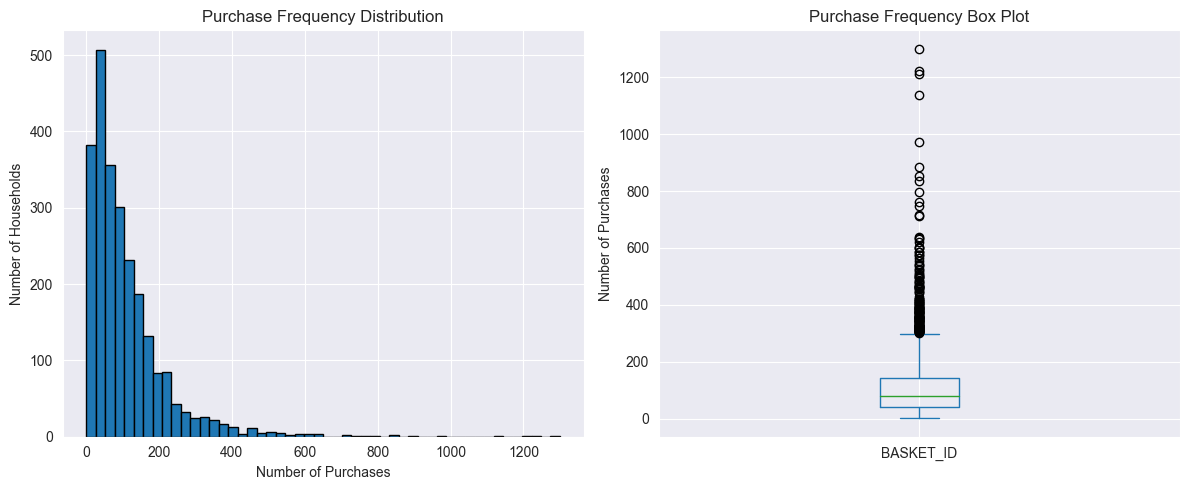

Mean purchases per household: 110.6
Median purchases per household: 79.0


In [4]:
# Purchase frequency distribution
purchase_freq = transactions.groupby('household_key')['BASKET_ID'].nunique()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
purchase_freq.hist(bins=50, edgecolor='black')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Households')
plt.title('Purchase Frequency Distribution')

plt.subplot(1, 2, 2)
purchase_freq.plot(kind='box')
plt.ylabel('Number of Purchases')
plt.title('Purchase Frequency Box Plot')
plt.tight_layout()
plt.show()

print(f"Mean purchases per household: {purchase_freq.mean():.1f}")
print(f"Median purchases per household: {purchase_freq.median():.1f}")

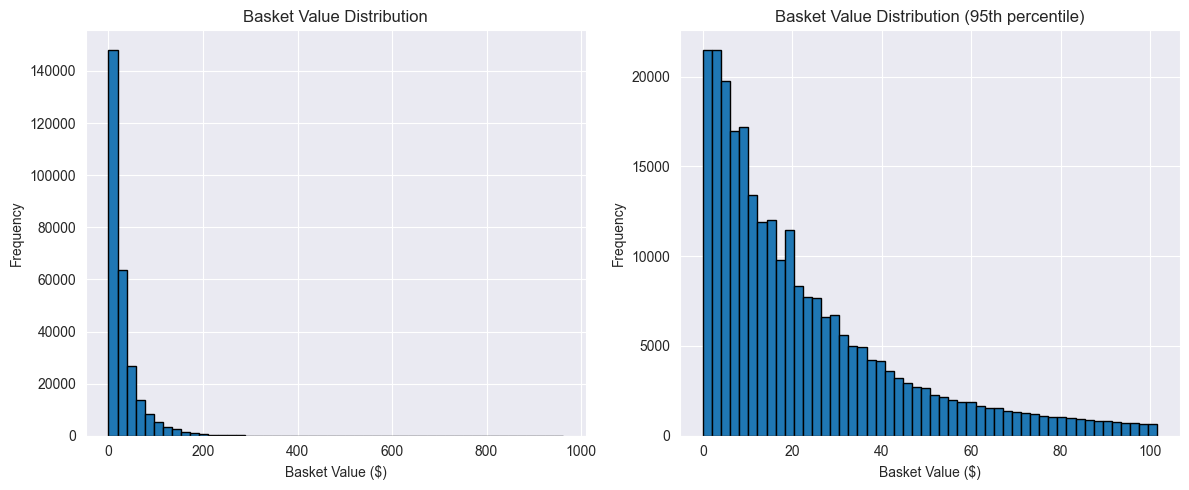

Mean basket value: $29.14
Median basket value: $17.07


In [5]:
# Basket value distribution
basket_value = transactions.groupby('BASKET_ID')['SALES_VALUE'].sum()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
basket_value.hist(bins=50, edgecolor='black')
plt.xlabel('Basket Value ($)')
plt.ylabel('Frequency')
plt.title('Basket Value Distribution')

plt.subplot(1, 2, 2)
basket_value[basket_value < basket_value.quantile(0.95)].hist(bins=50, edgecolor='black')
plt.xlabel('Basket Value ($)')
plt.ylabel('Frequency')
plt.title('Basket Value Distribution (95th percentile)')
plt.tight_layout()
plt.show()

print(f"Mean basket value: ${basket_value.mean():.2f}")
print(f"Median basket value: ${basket_value.median():.2f}")

## 3. Demographics Analysis

In [6]:
demographics.head()

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


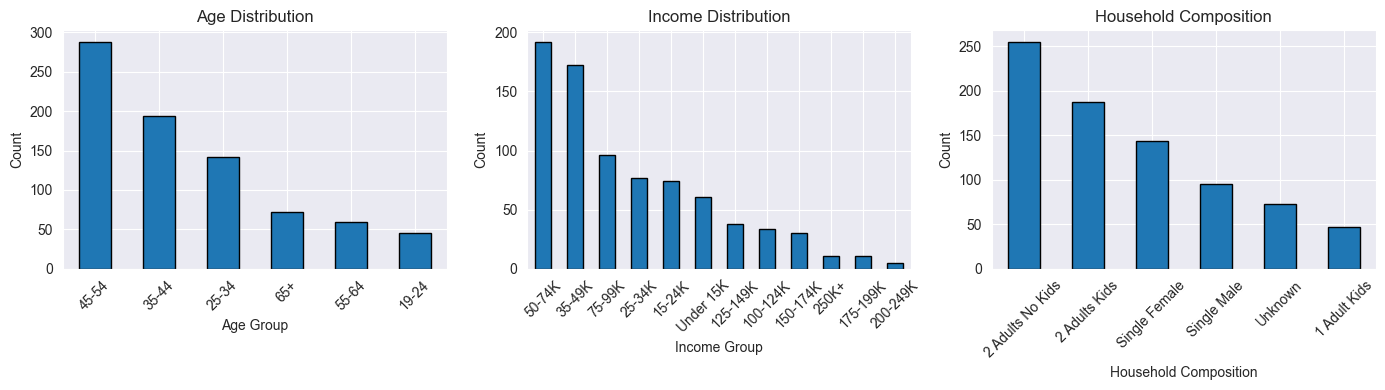

In [7]:
# Age distribution
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
demographics['AGE_DESC'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
demographics['INCOME_DESC'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Income Group')
plt.ylabel('Count')
plt.title('Income Distribution')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
demographics['HH_COMP_DESC'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Household Composition')
plt.ylabel('Count')
plt.title('Household Composition')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Campaign Analysis

In [8]:
# Campaign exposure
campaign_full = campaigns.merge(campaign_desc, on='CAMPAIGN')

print(f"Total campaign exposures: {len(campaign_full):,}")
print(f"Unique households exposed: {campaign_full['household_key'].nunique():,}")
print(f"\nCampaign types:")
print(campaign_full['CAMPAIGN'].value_counts())

Total campaign exposures: 7,208
Unique households exposed: 1,584

Campaign types:
18    1133
13    1077
8     1076
30     361
26     332
22     276
20     244
14     224
11     214
17     202
7      198
16     188
25     187
23     183
9      176
12     170
5      166
19     130
10     123
29     118
24     100
4       81
21      65
6       65
2       48
28      17
15      17
1       13
27      12
3       12
Name: CAMPAIGN, dtype: int64


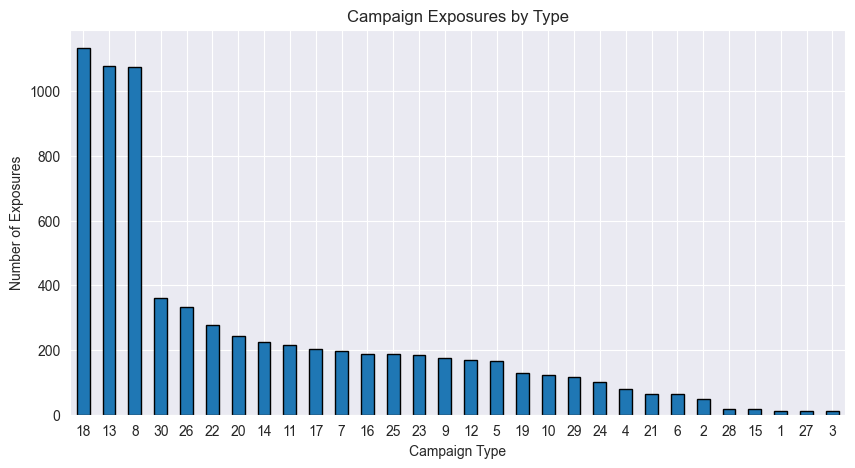

In [9]:
# Campaign exposure by type
plt.figure(figsize=(10, 5))
campaign_full['CAMPAIGN'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Campaign Type')
plt.ylabel('Number of Exposures')
plt.title('Campaign Exposures by Type')
plt.xticks(rotation=0)
plt.show()

## 5. Coupon Redemption Analysis

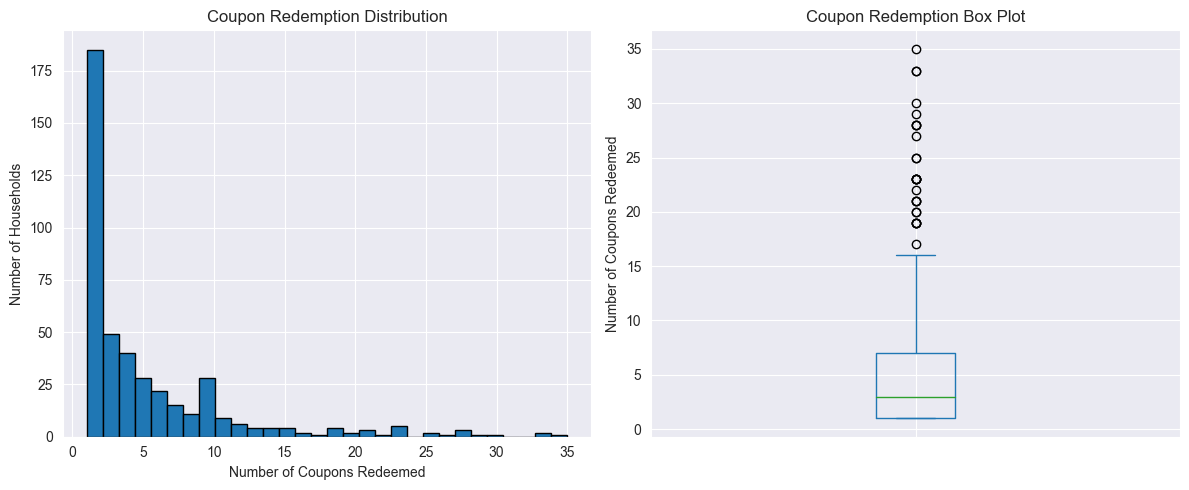

Households that redeemed coupons: 434
Mean redemptions per household: 5.3
Median redemptions per household: 3.0


In [10]:
# Coupon redemption rate
redemptions_per_hh = coupon_redempt.groupby('household_key').size()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
redemptions_per_hh.hist(bins=30, edgecolor='black')
plt.xlabel('Number of Coupons Redeemed')
plt.ylabel('Number of Households')
plt.title('Coupon Redemption Distribution')

plt.subplot(1, 2, 2)
redemptions_per_hh.plot(kind='box')
plt.ylabel('Number of Coupons Redeemed')
plt.title('Coupon Redemption Box Plot')
plt.tight_layout()
plt.show()

print(f"Households that redeemed coupons: {len(redemptions_per_hh):,}")
print(f"Mean redemptions per household: {redemptions_per_hh.mean():.1f}")
print(f"Median redemptions per household: {redemptions_per_hh.median():.1f}")

## 6. Treatment vs Control Comparison

In [11]:
# Define treatment (TypeA campaigns) vs control
treated_hh = campaign_full[campaign_full['DESCRIPTION_x'] == 'TypeA']['household_key'].unique()
all_hh = transactions['household_key'].unique()
control_hh = np.setdiff1d(all_hh, treated_hh)

print(f"Treatment group: {len(treated_hh):,} households ({len(treated_hh)/len(all_hh)*100:.1f}%)")
print(f"Control group: {len(control_hh):,} households ({len(control_hh)/len(all_hh)*100:.1f}%)")

Treatment group: 1,513 households (60.5%)
Control group: 987 households (39.5%)


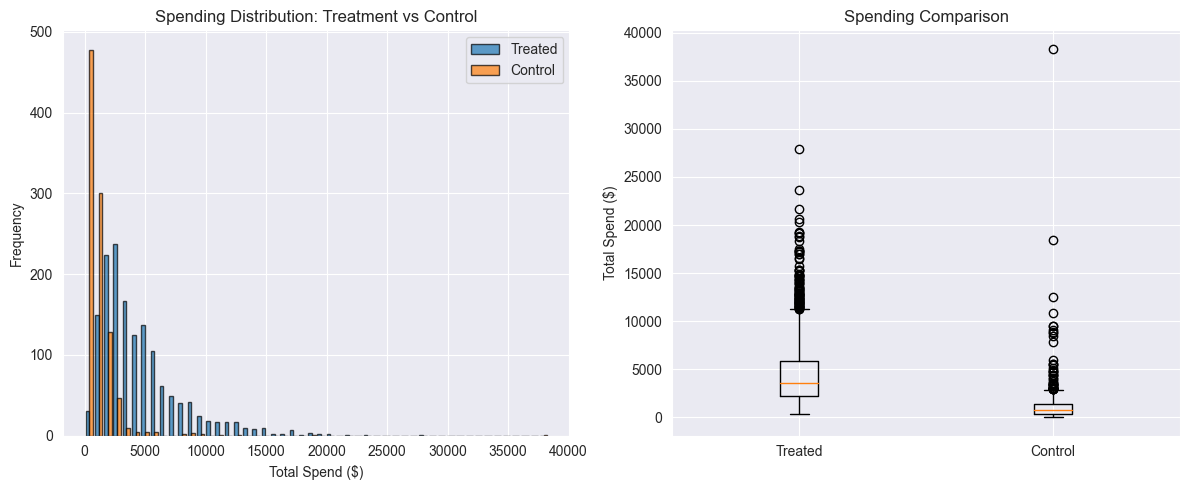

Mean spend (treated): $4583.89
Mean spend (control): $1136.81
Difference: $3447.08


In [12]:
# Compare spending between treatment and control
hh_spend = transactions.groupby('household_key')['SALES_VALUE'].sum()
treated_spend = hh_spend[hh_spend.index.isin(treated_hh)]
control_spend = hh_spend[hh_spend.index.isin(control_hh)]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist([treated_spend, control_spend], bins=50, label=['Treated', 'Control'], alpha=0.7, edgecolor='black')
plt.xlabel('Total Spend ($)')
plt.ylabel('Frequency')
plt.title('Spending Distribution: Treatment vs Control')
plt.legend()

plt.subplot(1, 2, 2)
data_to_plot = [treated_spend, control_spend]
plt.boxplot(data_to_plot, labels=['Treated', 'Control'])
plt.ylabel('Total Spend ($)')
plt.title('Spending Comparison')
plt.tight_layout()
plt.show()

print(f"Mean spend (treated): ${treated_spend.mean():.2f}")
print(f"Mean spend (control): ${control_spend.mean():.2f}")
print(f"Difference: ${treated_spend.mean() - control_spend.mean():.2f}")

## 7. Summary Statistics

In [13]:
# Overall summary
summary = {
    'Total Households': len(all_hh),
    'Total Transactions': len(transactions),
    'Total Revenue': f"${transactions['SALES_VALUE'].sum():,.2f}",
    'Avg Basket Value': f"${basket_value.mean():.2f}",
    'Avg Purchases per HH': f"{purchase_freq.mean():.1f}",
    'Campaign Exposures': len(campaign_full),
    'Coupon Redemptions': len(coupon_redempt),
    'Treatment Rate': f"{len(treated_hh)/len(all_hh)*100:.1f}%"
}

pd.DataFrame(summary.items(), columns=['Metric', 'Value'])

,Metric,Value
0,Total Households,2500
1,Total Transactions,2595732
2,Total Revenue,"$8,057,463.08"
3,Avg Basket Value,$29.14
4,Avg Purchases per HH,110.6
5,Campaign Exposures,7208
6,Coupon Redemptions,2318
7,Treatment Rate,60.5%
